# Day 12: Logistic Regression & Classification Metrics.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
# 1. Load Data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2,
random_state=42)
# 2. Scaling is CRITICAL for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 3. Train the Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
# 4. Predict
y_pred = model.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Model Accuracy: 0.9737


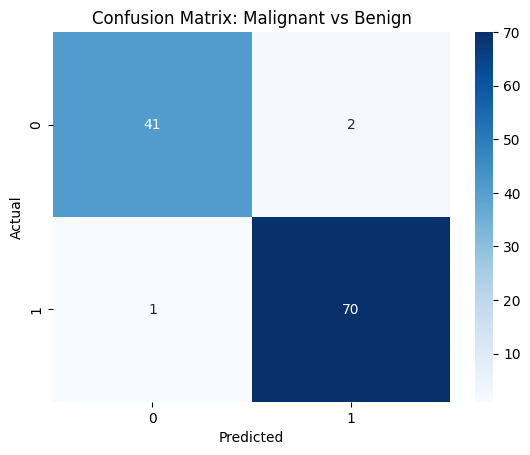

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Malignant vs Benign')
plt.show()

In [3]:
probs = model.predict_proba(X_test_scaled)
print(probs[:5])

[[1.14327437e-01 8.85672563e-01]
 [9.99990961e-01 9.03924655e-06]
 [9.96901657e-01 3.09834256e-03]
 [5.10962742e-04 9.99489037e-01]
 [6.08832659e-05 9.99939117e-01]]


predict() returns the final class (0 or 1).

predict_proba() returns probabilities for each class.

Example:
[0.03, 0.97] means 97% probability of malignant.

So, predict_proba() shows model confidence.

## Reflection: 
### In a medical scenario like cancer detection, which is worse: a False Positive (telling a healthy person they are sick) or a False Negative (telling a sick person they are healthy)? Why?

In a medical scenario like cancer detection, a False Negative is worse than a False Positive.

A False Negative means the model predicts a patient is healthy when they actually have cancer. This can delay treatment and lead to serious consequences.

A False Positive may cause stress, but further tests can correct the mistake.

Therefore, minimizing False Negatives is more important.